In [1]:
from sklearn.preprocessing import StandardScaler
from utils.evaluation import *
from utils.load_data import load_processed_data
from models.linear_regression import *
from torch.utils.data import DataLoader, Dataset

## Load data

In [2]:
data_path = '../data/processed/'
X_train, X_val, X_test, y_train, y_val, y_test = load_processed_data(data_path)

X_train shape: torch.Size([2111, 31]), y_train shape: torch.Size([2111, 1])
X_val shape: torch.Size([453, 31]), y_val shape: torch.Size([453, 1])
X_test shape: torch.Size([453, 31]), y_test shape: torch.Size([453, 1])


## Train Linear Regression with sklearn

In [3]:
lr_sklearn = LinearRegressionSklearn()
lr_sklearn.fit(X_train, y_train)

In [4]:
test_model(lr_sklearn, X_val, y_val)
test_model(lr_sklearn, X_test, y_test)


========= Model Evaluation =========
Mean Squared Error (MSE): 183.2628
R^2 Score: 0.7873

========= Model Evaluation =========
Mean Squared Error (MSE): 177.7014
R^2 Score: 0.7566


## Train Linear Regression using Numpy

In [5]:
lr_numpy = LinearRegressionNumpy(n_features=X_train.shape[1], lr=0.2)
train_losses, val_losses = lr_numpy.fit(X_train, y_train, X_val, y_val, epochs=4000)

Epoch [400/4000], Train Loss: 282.5991, Val Loss: 352.2924
Epoch [800/4000], Train Loss: 243.6729, Val Loss: 299.5536
Epoch [1200/4000], Train Loss: 219.2326, Val Loss: 264.0615
Epoch [1600/4000], Train Loss: 203.7769, Val Loss: 240.1070
Epoch [2000/4000], Train Loss: 193.9822, Val Loss: 223.7872
Epoch [2400/4000], Train Loss: 187.7656, Val Loss: 212.5400
Epoch [2800/4000], Train Loss: 183.8142, Val Loss: 204.6906
Epoch [3200/4000], Train Loss: 181.2985, Val Loss: 199.1401
Epoch [3600/4000], Train Loss: 179.6937, Val Loss: 195.1625
Epoch [4000/4000], Train Loss: 178.6677, Val Loss: 192.2744


In [6]:
test_model(lr_numpy, X_test, y_test)


========= Model Evaluation =========
Mean Squared Error (MSE): 181.1827
R^2 Score: 0.7518


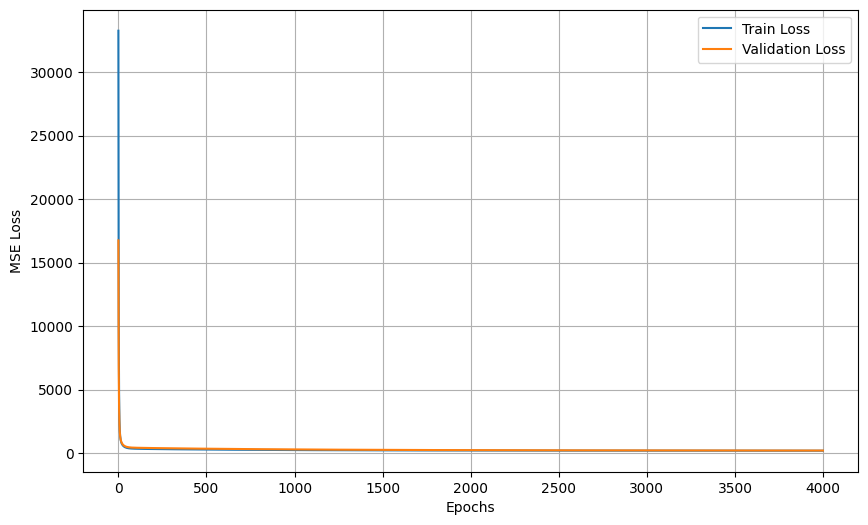

In [7]:
plot_loss(train_losses, val_losses)

## Train Linear Regression using Torch

In [8]:
class CustomDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

batch_size = 32

train_dataset = CustomDataset(X_train, y_train)
val_dataset = CustomDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

In [9]:
lr_torch = LinearRegressionTorch(X_train.shape[1], lr=0.05)
train_losses, val_losses = lr_torch.fit(train_loader, val_loader, epochs=1000)

Epoch [100/1000], Train Loss: 192.9889, Val Loss: 214.2079
Epoch [200/1000], Train Loss: 193.0252, Val Loss: 210.4385
Epoch [300/1000], Train Loss: 194.0479, Val Loss: 210.5983
Epoch [400/1000], Train Loss: 192.6235, Val Loss: 208.1959
Epoch [500/1000], Train Loss: 194.3487, Val Loss: 218.0304
Epoch [600/1000], Train Loss: 189.4542, Val Loss: 197.9924
Epoch [700/1000], Train Loss: 195.5430, Val Loss: 207.2245
Epoch [800/1000], Train Loss: 190.5226, Val Loss: 217.5531
Epoch [900/1000], Train Loss: 193.8580, Val Loss: 194.3503
Epoch [1000/1000], Train Loss: 195.3672, Val Loss: 199.0291


In [10]:
test_model(lr_torch, X_test, y_test)


========= Model Evaluation =========
Mean Squared Error (MSE): 176.9911
R^2 Score: 0.7576


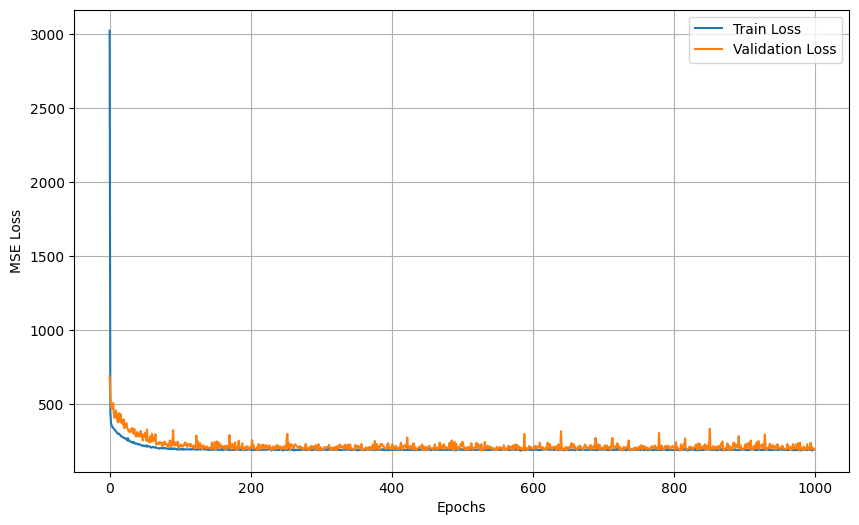

In [11]:
plot_loss(train_losses, val_losses)